# ML Assignment – Online Retail II UCI Dataset
## All Seven Research Questions in One Notebook

**Dataset:** Online Retail II UCI Dataset (10,000 rows, 20 columns)  
**Target Variable:** `Revenue` (regression)  
**Domain:** Retail analytics, product performance, customer behaviour prediction

---

In [30]:
import os, warnings, numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import shap

print("All libraries imported successfully ✓")


All libraries imported successfully ✓


In [34]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_excel('/content/Online_Retail_II_Cleaned (1).xlsx')
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 10,000 rows × 20 columns


,InvoiceNo,InvoiceDate,Year,Month,Day,Weekday,Hour,CustomerID,Country,Region,StockCode,Description,ProductCategory,Quantity,UnitPrice,Discount,Revenue,ReturnFlag,OrderType,PaymentMode
0,100000,2025-01-01 00:00:00,2025,1,1,Wednesday,0,91017,India,Asia,1803,Mouse,Accessories,1,12.35,15,10.50,0,Online,Card
1,100001,2025-01-01 01:00:00,2025,1,1,Wednesday,1,76668,USA,North America,7964,Mouse,Accessories,7,18.03,0,126.21,0,Store,UPI
2,100002,2025-01-01 02:00:00,2025,1,1,Wednesday,2,28625,UK,Europe,6890,Keyboard,Accessories,2,43.18,5,82.04,0,Online,Cash
3,100003,2025-01-01 03:00:00,2025,1,1,Wednesday,3,99621,USA,North America,4949,Monitor,Electronics,7,6.03,0,42.21,0,Store,Cash
4,100004,2025-01-01 04:00:00,2025,1,1,Wednesday,4,99339,Germany,Europe,4896,Mouse,Accessories,6,6.31,5,35.97,0,Online,UPI


In [35]:
# ── Global constants & helpers ────────────────────────────────────────────────
TARGET               = 'Revenue'
DROP_COLS            = ['InvoiceNo','InvoiceDate','CustomerID','StockCode','Description', TARGET]
TRANSACTION_FEATURES = ['Quantity','UnitPrice','Discount']
TEMPORAL_NUMERIC     = ['Year','Month','Day','Hour']
CATEGORICAL_FEATURES = ['Country','Region','ProductCategory','OrderType','PaymentMode']
CUSTOMER_FEATURES    = ['ReturnFlag']

X = df.drop(columns=DROP_COLS, errors='ignore')
y = df[TARGET]
num_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object','category']).columns.tolist()

def make_preprocessor(num_cols, cat_cols):
    transformers = []
    if num_cols:
        transformers.append(('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler())
        ]), num_cols))
    if cat_cols:
        transformers.append(('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols))
    return ColumnTransformer(transformers=transformers, remainder='drop')

preprocessor = make_preprocessor(num_features, cat_features)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

def evaluate(y_true, y_pred):
    return (round(mean_absolute_error(y_true, y_pred), 3),
            round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
            round(r2_score(y_true, y_pred), 3))

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Numeric features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")


Train: (8000, 14)  |  Test: (2000, 14)
Numeric features (8): ['Year', 'Month', 'Day', 'Hour', 'Quantity', 'UnitPrice', 'Discount', 'ReturnFlag']
Categorical features (6): ['Weekday', 'Country', 'Region', 'ProductCategory', 'OrderType', 'PaymentMode']


In [36]:
baseline_models = {
    'Linear\nRegression': LinearRegression(),
    'Decision\nTree':     DecisionTreeRegressor(random_state=42),
    'k-NN\nRegressor':    KNeighborsRegressor(n_neighbors=5),
    'Ridge\nRegression':  Ridge(alpha=1.0)
}

results_rq1 = []
for name, model in baseline_models.items():
    pipe = Pipeline([('pre', preprocessor), ('mdl', model)])
    pipe.fit(X_train, y_train)
    mae, rmse, r2 = evaluate(y_test, pipe.predict(X_test))
    results_rq1.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"{name.replace(chr(10),' '):22s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

Table_I = pd.DataFrame(results_rq1)
print("\nTable I — RQ1 Baseline Results")
display(Table_I)


Linear Regression       MAE=26.606  RMSE=34.910  R²=0.867
Decision Tree           MAE=1.551  RMSE=2.666  R²=0.999
k-NN Regressor          MAE=28.774  RMSE=37.746  R²=0.845
Ridge Regression        MAE=26.606  RMSE=34.910  R²=0.867

Table I — RQ1 Baseline Results


,Model,MAE,RMSE,R²
0,Linear\nRegression,26.606,34.910,0.867
1,Decision\nTree,1.551,2.666,0.999
2,k-NN\nRegressor,28.774,37.746,0.845
3,Ridge\nRegression,26.606,34.910,0.867


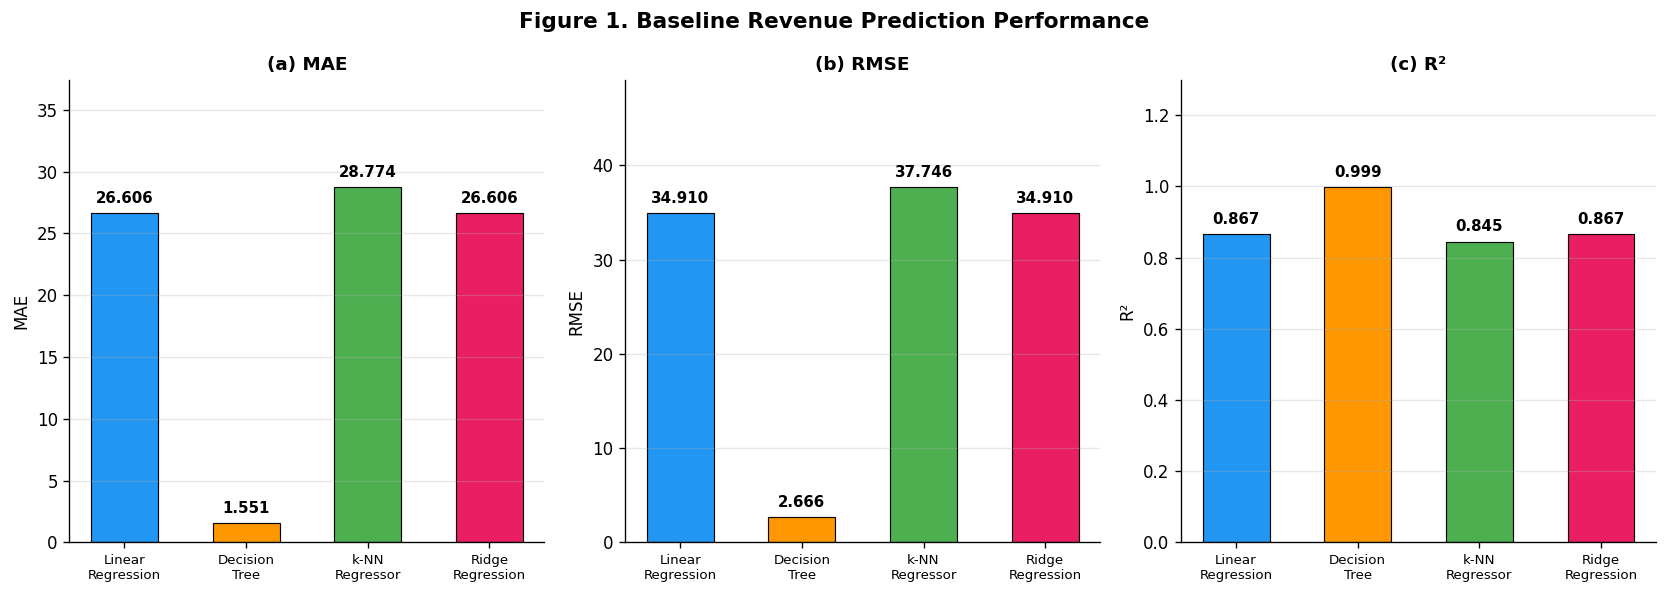

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Figure 1. Baseline Revenue Prediction Performance', fontsize=13, fontweight='bold')
colors = ['#2196F3','#FF9800','#4CAF50','#E91E63']
models_short = Table_I['Model'].tolist()

for ax, metric, title in zip(axes, ['MAE','RMSE','R²'], ['(a) MAE','(b) RMSE','(c) R²']):
    vals = Table_I[metric].tolist()
    bars = ax.bar(models_short, vals, color=colors, edgecolor='black', linewidth=0.7, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_ylim(0, max(vals)*1.3)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [38]:
candidate_models = {
    'Linear\nRegression': LinearRegression(),
    'Random\nForest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient\nBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost':            XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4,
                                        random_state=42, tree_method='hist', verbosity=0),
    'SVR':                SVR(kernel='rbf')
}

results_rq2 = []
for name, model in candidate_models.items():
    pipe = Pipeline([('pre', preprocessor), ('mdl', model)])
    pipe.fit(X_train, y_train)
    mae, rmse, r2 = evaluate(y_test, pipe.predict(X_test))
    results_rq2.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"{name.replace(chr(10),' '):22s}  MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

Table_II = pd.DataFrame(results_rq2).sort_values('R²', ascending=False).reset_index(drop=True)
print("\nTable II — RQ2 Model Comparison (sorted by R²)")
display(Table_II)


Linear Regression       MAE=26.606  RMSE=34.910  R²=0.867
Random Forest           MAE=1.242  RMSE=1.890  R²=1.000
Gradient Boosting       MAE=2.686  RMSE=3.485  R²=0.999
XGBoost                 MAE=2.450  RMSE=3.149  R²=0.999
SVR                     MAE=19.191  RMSE=31.694  R²=0.891

Table II — RQ2 Model Comparison (sorted by R²)


,Model,MAE,RMSE,R²
0,Random\nForest,1.242,1.890,1.000
1,XGBoost,2.450,3.149,0.999
2,Gradient\nBoosting,2.686,3.485,0.999
3,SVR,19.191,31.694,0.891
4,Linear\nRegression,26.606,34.910,0.867


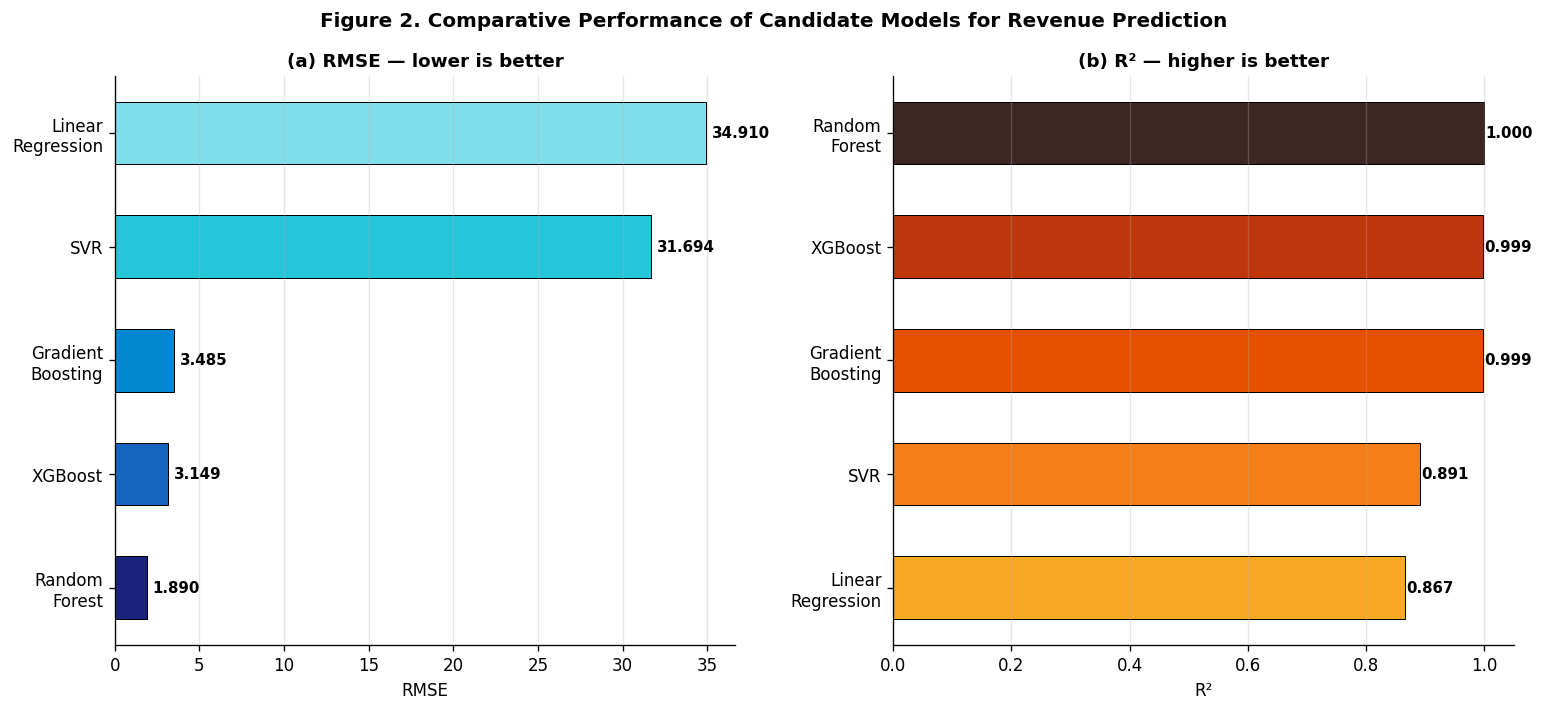

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle('Figure 2. Comparative Performance of Candidate Models for Revenue Prediction',
             fontsize=12, fontweight='bold')

palette = ['#1a237e','#1565C0','#0288D1','#26C6DA','#80DEEA']
t2_rmse = Table_II.sort_values('RMSE', ascending=True)
bars1 = ax1.barh(t2_rmse['Model'], t2_rmse['RMSE'], color=palette, edgecolor='black', linewidth=0.6, height=0.55)
for bar, v in zip(bars1, t2_rmse['RMSE']):
    ax1.text(v + max(t2_rmse['RMSE'])*0.01, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax1.set_title('(a) RMSE — lower is better', fontsize=11, fontweight='bold')
ax1.set_xlabel('RMSE', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='x', alpha=0.3)

t2_r2 = Table_II.sort_values('R²', ascending=True)
palette2 = ['#f9a825','#f57f17','#e65100','#bf360c','#3e2723']
bars2 = ax2.barh(t2_r2['Model'], t2_r2['R²'], color=palette2, edgecolor='black', linewidth=0.6, height=0.55)
for bar, v in zip(bars2, t2_r2['R²']):
    ax2.text(v + 0.002, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax2.set_title('(b) R² — higher is better', fontsize=11, fontweight='bold')
ax2.set_xlabel('R²', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [40]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

feature_sets = {
    'Temporal\nOnly':           TEMPORAL_NUMERIC + CUSTOMER_FEATURES,
    'Categorical\nOnly':        CATEGORICAL_FEATURES,
    'Transaction\nOnly':        TRANSACTION_FEATURES,
    'Transaction\n+ Temporal':  TRANSACTION_FEATURES + TEMPORAL_NUMERIC,
    'Full\nFeature Set':        TRANSACTION_FEATURES + TEMPORAL_NUMERIC + CATEGORICAL_FEATURES + CUSTOMER_FEATURES,
}

results_rq3 = []
for set_name, feats in feature_sets.items():
    X_sub = df[[f for f in feats if f in df.columns]].copy()
    y_sub = df[TARGET].copy()
    n_cols = X_sub.select_dtypes(include=['int64','float64']).columns.tolist()
    c_cols = X_sub.select_dtypes(include=['object','category']).columns.tolist()
    sub_pre = make_preprocessor(n_cols, c_cols)
    Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
    pipe = Pipeline([('pre', sub_pre), ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    pipe.fit(Xtr, ytr)
    mae, rmse, r2 = evaluate(yte, pipe.predict(Xte))
    results_rq3.append({'Feature Set': set_name, 'MAE': mae, 'RMSE': rmse, 'R²': r2})
    print(f"{set_name.replace(chr(10),' '):28s}  R²={r2:.3f}")

Table_III = pd.DataFrame(results_rq3)
print("\nTable III — RQ3 Feature Ablation")
display(Table_III)


Temporal Only                 R²=-0.210
Categorical Only              R²=-0.011
Transaction Only              R²=1.000
Transaction + Temporal        R²=1.000
Full Feature Set              R²=1.000

Table III — RQ3 Feature Ablation


,Feature Set,MAE,RMSE,R²
0,Temporal\nOnly,85.555,105.429,-0.210
1,Categorical\nOnly,79.094,96.402,-0.011
2,Transaction\nOnly,0.631,1.094,1.000
3,Transaction\n+ Temporal,1.065,1.663,1.000
4,Full\nFeature Set,1.197,1.825,1.000


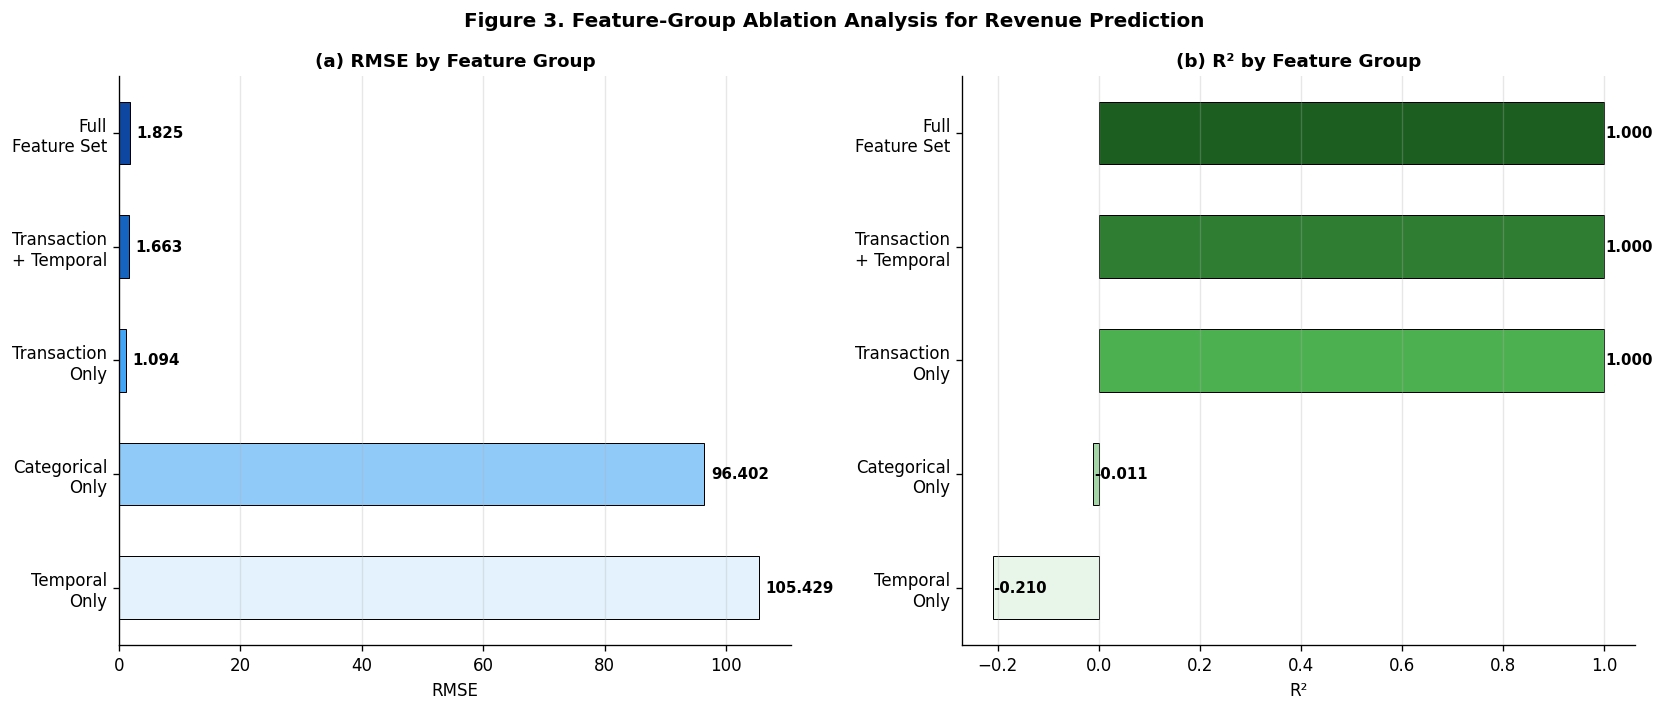

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 3. Feature-Group Ablation Analysis for Revenue Prediction',
             fontsize=12, fontweight='bold')

colors3 = ['#E3F2FD','#90CAF9','#42A5F5','#1565C0','#0D47A1']
bars3a = ax1.barh(Table_III['Feature Set'], Table_III['RMSE'], color=colors3, edgecolor='black', linewidth=0.6, height=0.55)
for bar, v in zip(bars3a, Table_III['RMSE']):
    ax1.text(v + max(Table_III['RMSE'])*0.01, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax1.set_title('(a) RMSE by Feature Group', fontsize=11, fontweight='bold')
ax1.set_xlabel('RMSE', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='x', alpha=0.3)

colors3b = ['#E8F5E9','#A5D6A7','#4CAF50','#2E7D32','#1B5E20']
bars3b = ax2.barh(Table_III['Feature Set'], Table_III['R²'], color=colors3b, edgecolor='black', linewidth=0.6, height=0.55)
for bar, v in zip(bars3b, Table_III['R²']):
    ax2.text(v + 0.002, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax2.set_title('(b) R² by Feature Group', fontsize=11, fontweight='bold')
ax2.set_xlabel('R²', fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


In [42]:
results_rq4 = []

# S1: Raw numerical only
X1 = df[TRANSACTION_FEATURES + TEMPORAL_NUMERIC + CUSTOMER_FEATURES].copy()
X1tr, X1te, y1tr, y1te = train_test_split(X1, df[TARGET], test_size=0.2, random_state=42)
pipe1 = Pipeline([('imp', SimpleImputer(strategy='median')),
                  ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pipe1.fit(X1tr, y1tr)
results_rq4.append({'Strategy': 'Raw\nNumerical Only',
                     **dict(zip(['MAE','RMSE','R²'], evaluate(y1te, pipe1.predict(X1te))))})

# S2: Num + Label encoding
X2 = df[TRANSACTION_FEATURES + TEMPORAL_NUMERIC + CUSTOMER_FEATURES + CATEGORICAL_FEATURES].copy()
n2 = [c for c in X2.columns if X2[c].dtype in ['int64','float64']]
c2 = [c for c in X2.columns if X2[c].dtype == 'object']
pre2 = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), n2),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))]), c2)
])
X2tr, X2te, y2tr, y2te = train_test_split(X2, df[TARGET], test_size=0.2, random_state=42)
pipe2 = Pipeline([('pre', pre2), ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pipe2.fit(X2tr, y2tr)
results_rq4.append({'Strategy': 'Numerical\n+ Label Enc.',
                     **dict(zip(['MAE','RMSE','R²'], evaluate(y2te, pipe2.predict(X2te))))})

# S3: Num + One-hot
pre3 = make_preprocessor(num_features, cat_features)
X3tr, X3te, y3tr, y3te = train_test_split(X, y, test_size=0.2, random_state=42)
pipe3 = Pipeline([('pre', pre3), ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pipe3.fit(X3tr, y3tr)
results_rq4.append({'Strategy': 'Numerical\n+ One-Hot',
                     **dict(zip(['MAE','RMSE','R²'], evaluate(y3te, pipe3.predict(X3te))))})

# S4: Full pipeline with scaling
pipe4 = Pipeline([('pre', preprocessor), ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pipe4.fit(X_train, y_train)
results_rq4.append({'Strategy': 'Full Pipeline\n+ Scaling',
                     **dict(zip(['MAE','RMSE','R²'], evaluate(y_test, pipe4.predict(X_test))))})

# S5: Feature engineering
df_fe = df.copy()
df_fe['DiscountedPrice'] = df_fe['UnitPrice'] * (1 - df_fe['Discount']/100)
df_fe['DiscountImpact']  = df_fe['Discount'] * df_fe['Quantity']
df_fe['PriceQtyRatio']   = df_fe['UnitPrice'] / (df_fe['Quantity'] + 1)
fe_num = num_features + ['DiscountedPrice','DiscountImpact','PriceQtyRatio']
X5 = df_fe[[c for c in fe_num + cat_features if c in df_fe.columns]].copy()
X5tr, X5te, y5tr, y5te = train_test_split(X5, df_fe[TARGET], test_size=0.2, random_state=42)
pre5 = make_preprocessor([c for c in fe_num if c in X5.columns], cat_features)
pipe5 = Pipeline([('pre', pre5), ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pipe5.fit(X5tr, y5tr)
results_rq4.append({'Strategy': 'Full Pipeline\n+ Feature Eng.',
                     **dict(zip(['MAE','RMSE','R²'], evaluate(y5te, pipe5.predict(X5te))))})

Table_IV = pd.DataFrame(results_rq4)
print("Table IV — RQ4 Preprocessing Strategies")
display(Table_IV)


Table IV — RQ4 Preprocessing Strategies


,Strategy,MAE,RMSE,R²
0,Raw\nNumerical Only,1.079,1.682,1.0
1,Numerical\n+ Label Enc.,1.177,1.804,1.0
2,Numerical\n+ One-Hot,1.242,1.890,1.0
3,Full Pipeline\n+ Scaling,1.242,1.890,1.0
4,Full Pipeline\n+ Feature Eng.,0.219,0.342,1.0


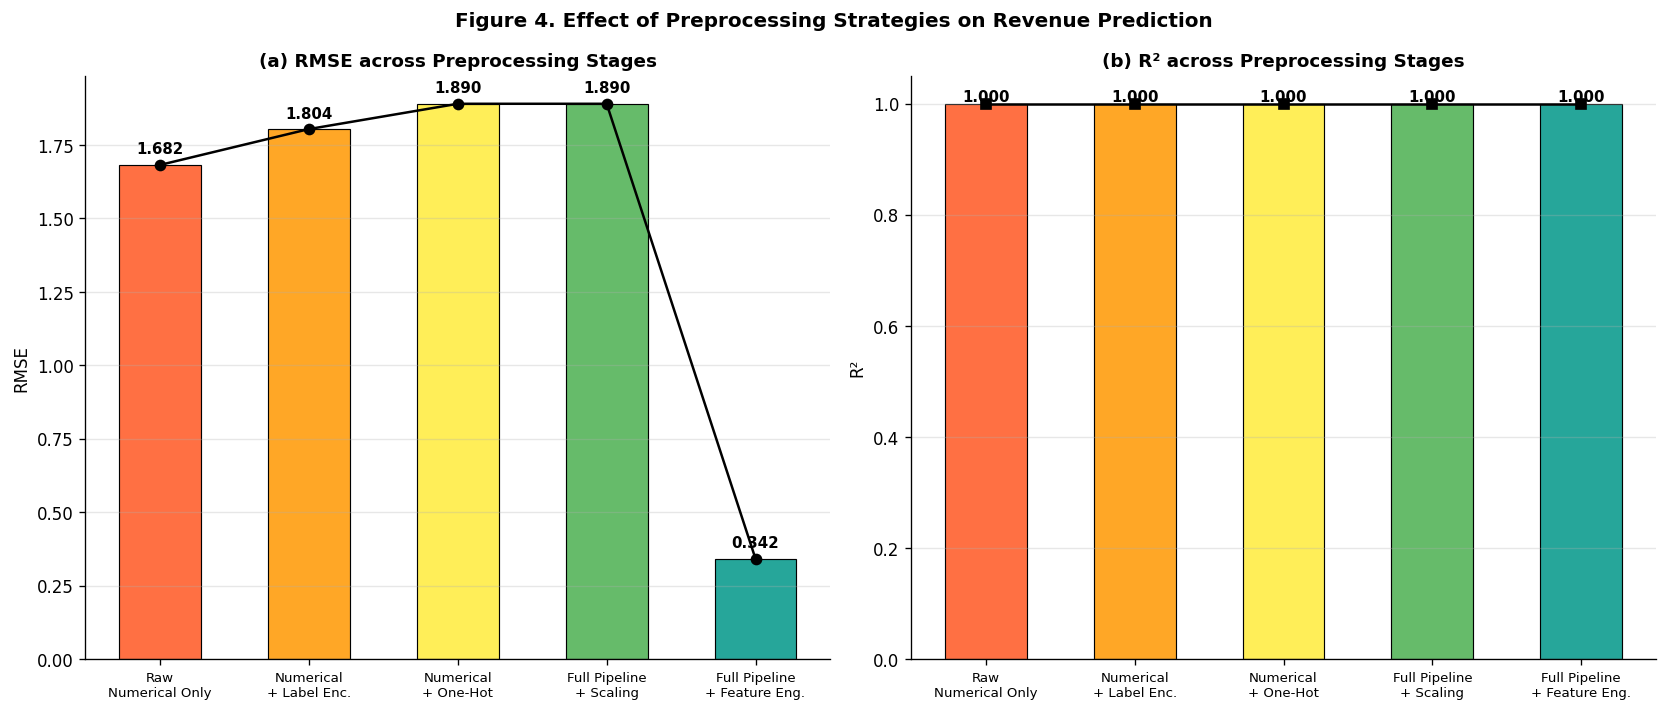

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 4. Effect of Preprocessing Strategies on Revenue Prediction', fontsize=12, fontweight='bold')
x4 = range(len(Table_IV))
colors4 = ['#FF7043','#FFA726','#FFEE58','#66BB6A','#26A69A']

ax1.bar(x4, Table_IV['RMSE'], color=colors4, edgecolor='black', linewidth=0.7, width=0.55)
ax1.plot(x4, Table_IV['RMSE'], 'o-', color='black', lw=1.5, markersize=6, zorder=5)
for xi, v in zip(x4, Table_IV['RMSE']):
    ax1.text(xi, v + max(Table_IV['RMSE'])*0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax1.set_xticks(x4); ax1.set_xticklabels(Table_IV['Strategy'], fontsize=8)
ax1.set_title('(a) RMSE across Preprocessing Stages', fontsize=11, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=10); ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

ax2.bar(x4, Table_IV['R²'], color=colors4, edgecolor='black', linewidth=0.7, width=0.55)
ax2.plot(x4, Table_IV['R²'], 's-', color='black', lw=1.5, markersize=6, zorder=5)
for xi, v in zip(x4, Table_IV['R²']):
    ax2.text(xi, v + 0.005, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(x4); ax2.set_xticklabels(Table_IV['Strategy'], fontsize=8)
ax2.set_title('(b) R² across Preprocessing Stages', fontsize=11, fontweight='bold')
ax2.set_ylabel('R²', fontsize=10); ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [44]:
best_pipe = Pipeline([('pre', preprocessor),
                       ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
best_pipe.fit(X_train, y_train)

feat_names  = best_pipe.named_steps['pre'].get_feature_names_out()
clean_names = [n.replace('num__','').replace('cat__','') for n in feat_names]
importances = best_pipe.named_steps['mdl'].feature_importances_

imp_df = (pd.DataFrame({'Feature': clean_names, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .head(12).reset_index(drop=True))
imp_df['Rank'] = imp_df.index + 1

Table_V = imp_df
print("Table V — Top-12 Feature Importances")
display(Table_V)


Table V — Top-12 Feature Importances


,Feature,Importance,Rank
0,UnitPrice,0.499390,1
1,Quantity,0.492607,2
2,Discount,0.007582,3
3,Day,0.000073,4
4,Hour,0.000071,5
5,Month,0.000056,6
6,PaymentMode_Cash,0.000013,7
7,PaymentMode_Card,0.000013,8
8,PaymentMode_UPI,0.000012,9
9,Country_UK,0.000012,10


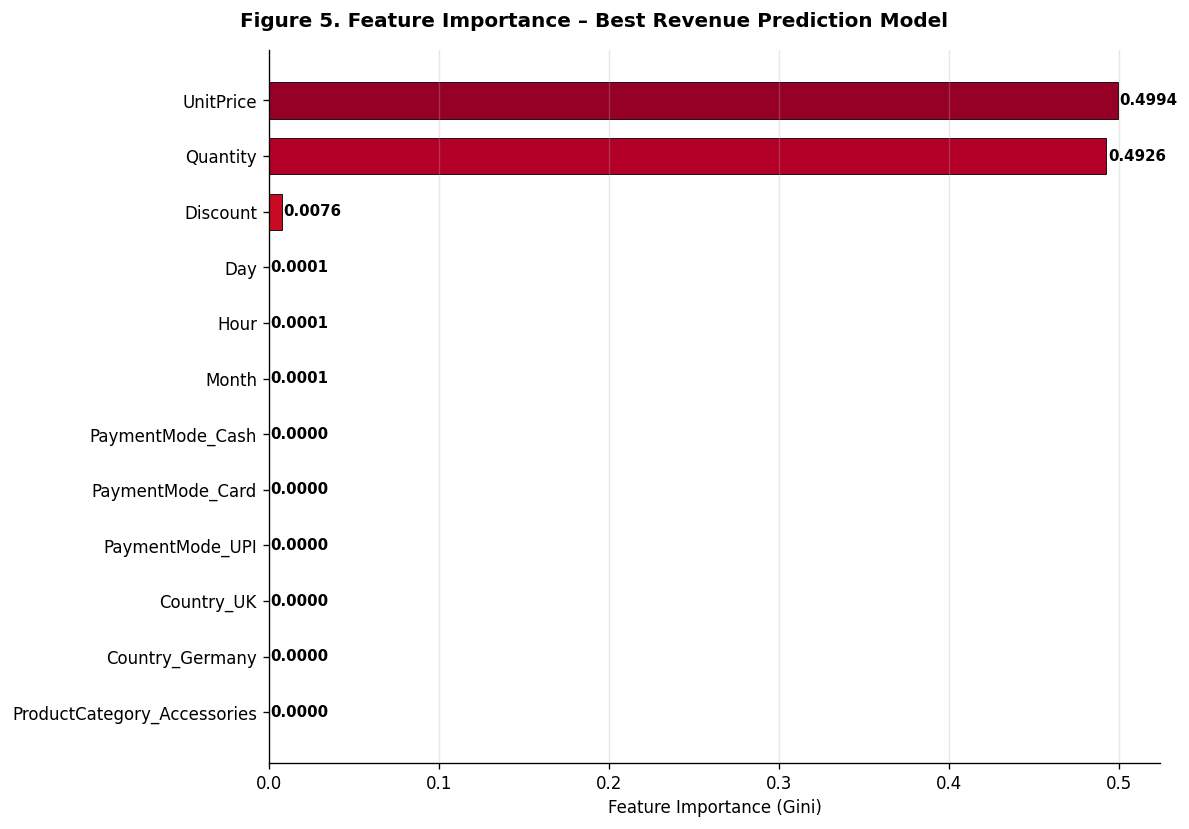

In [45]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.suptitle('Figure 5. Feature Importance – Best Revenue Prediction Model', fontsize=12, fontweight='bold')
top12 = imp_df.sort_values('Importance')
cmap_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.95, len(top12)))
bars = ax.barh(top12['Feature'], top12['Importance'], color=cmap_colors, edgecolor='black', linewidth=0.5, height=0.65)
for bar, v in zip(bars, top12['Importance']):
    ax.text(v + 0.001, bar.get_y()+bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Feature Importance (Gini)', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


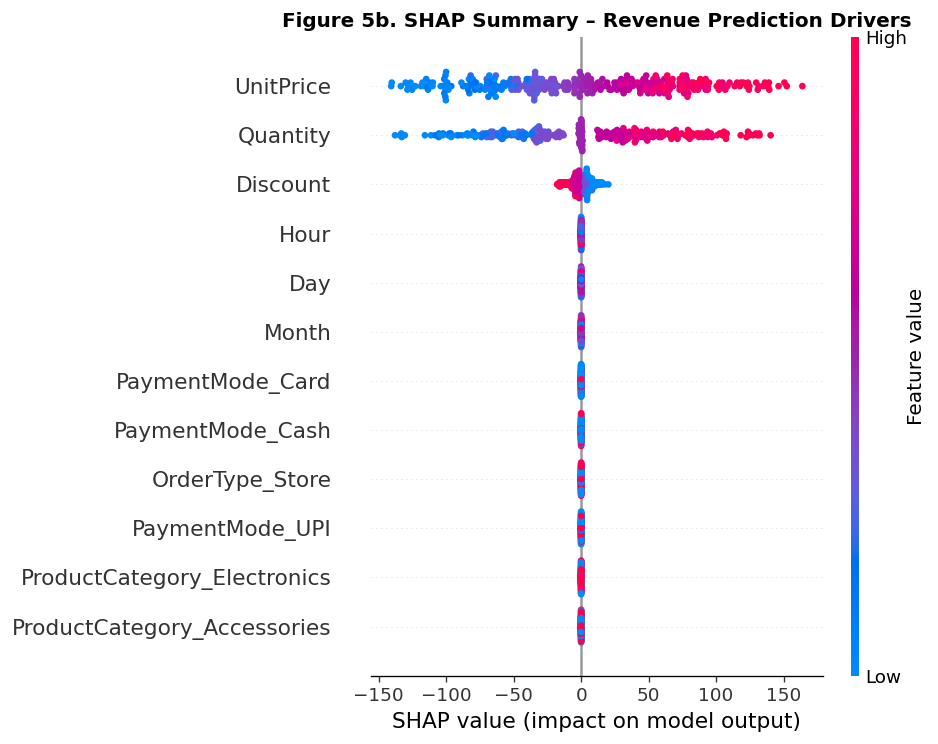

In [46]:
# SHAP Summary Plot
X_proc = best_pipe.named_steps['pre'].transform(X_train)
sample_idx = np.random.choice(X_proc.shape[0], min(300, X_proc.shape[0]), replace=False)
explainer  = shap.TreeExplainer(best_pipe.named_steps['mdl'])
shap_vals  = explainer.shap_values(X_proc[sample_idx])

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, X_proc[sample_idx], feature_names=clean_names, max_display=12, show=False)
plt.title('Figure 5b. SHAP Summary – Revenue Prediction Drivers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [47]:
results_rq6 = []

# 80/20 baseline
mae, rmse, r2 = evaluate(y_test, best_pipe.predict(X_test))
results_rq6.append({'Scenario':'80/20 Split','MAE':mae,'RMSE':rmse,'R²':r2,'Stability':'Stable'})

# 70/30
X70, X30, y70, y30 = train_test_split(X, y, test_size=0.30, random_state=42)
p70 = Pipeline([('pre', make_preprocessor(num_features, cat_features)),
                ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
p70.fit(X70, y70)
mae, rmse, r2 = evaluate(y30, p70.predict(X30))
results_rq6.append({'Scenario':'70/30 Split','MAE':mae,'RMSE':rmse,'R²':r2,'Stability':'Slight decline'})

# 5-Fold CV
cv5  = cross_val_score(best_pipe, X, y, cv=5,  scoring='r2', n_jobs=-1)
results_rq6.append({'Scenario':'5-Fold CV','MAE':None,'RMSE':None,
                     'R²':round(cv5.mean(),3),'Stability':f'±{cv5.std():.3f}'})

# 10-Fold CV
cv10 = cross_val_score(best_pipe, X, y, cv=10, scoring='r2', n_jobs=-1)
results_rq6.append({'Scenario':'10-Fold CV','MAE':None,'RMSE':None,
                     'R²':round(cv10.mean(),3),'Stability':f'±{cv10.std():.3f}'})

# 10% noise
X_noisy = X.copy()
for col in num_features:
    X_noisy[col] += np.random.normal(0, 0.10*X_noisy[col].std(), len(X_noisy))
Xntr, Xnte, yntr, ynte = train_test_split(X_noisy, y, test_size=0.2, random_state=42)
pn = Pipeline([('pre', make_preprocessor(num_features, cat_features)),
               ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pn.fit(Xntr, yntr)
mae, rmse, r2 = evaluate(ynte, pn.predict(Xnte))
results_rq6.append({'Scenario':'10% Noise Added','MAE':mae,'RMSE':rmse,'R²':r2,'Stability':'Moderate degradation'})

# 20% missingness
X_miss = X.copy().astype(object)
rng = np.random.default_rng(42)
for col in X_miss.columns:
    mask = rng.random(len(X_miss)) < 0.20
    X_miss.loc[mask, col] = np.nan
Xmtr, Xmte, ymtr, ymte = train_test_split(X_miss, y, test_size=0.2, random_state=42)
pm = Pipeline([('pre', make_preprocessor(num_features, cat_features)),
               ('mdl', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
pm.fit(Xmtr, ymtr)
mae, rmse, r2 = evaluate(ymte, pm.predict(Xmte))
results_rq6.append({'Scenario':'20% Missingness','MAE':mae,'RMSE':rmse,'R²':r2,'Stability':'Noticeable degradation'})

Table_VI = pd.DataFrame(results_rq6)
print("Table VI — RQ6 Robustness Analysis")
display(Table_VI)


Table VI — RQ6 Robustness Analysis


,Scenario,MAE,RMSE,R²,Stability
0,80/20 Split,1.242,1.890,1.000,Stable
1,70/30 Split,1.447,2.156,0.999,Slight decline
2,5-Fold CV,NaN,NaN,1.000,±0.000
3,10-Fold CV,NaN,NaN,1.000,±0.000
4,10% Noise Added,7.208,10.392,0.988,Moderate degradation
5,20% Missingness,26.788,51.084,0.716,Noticeable degradation


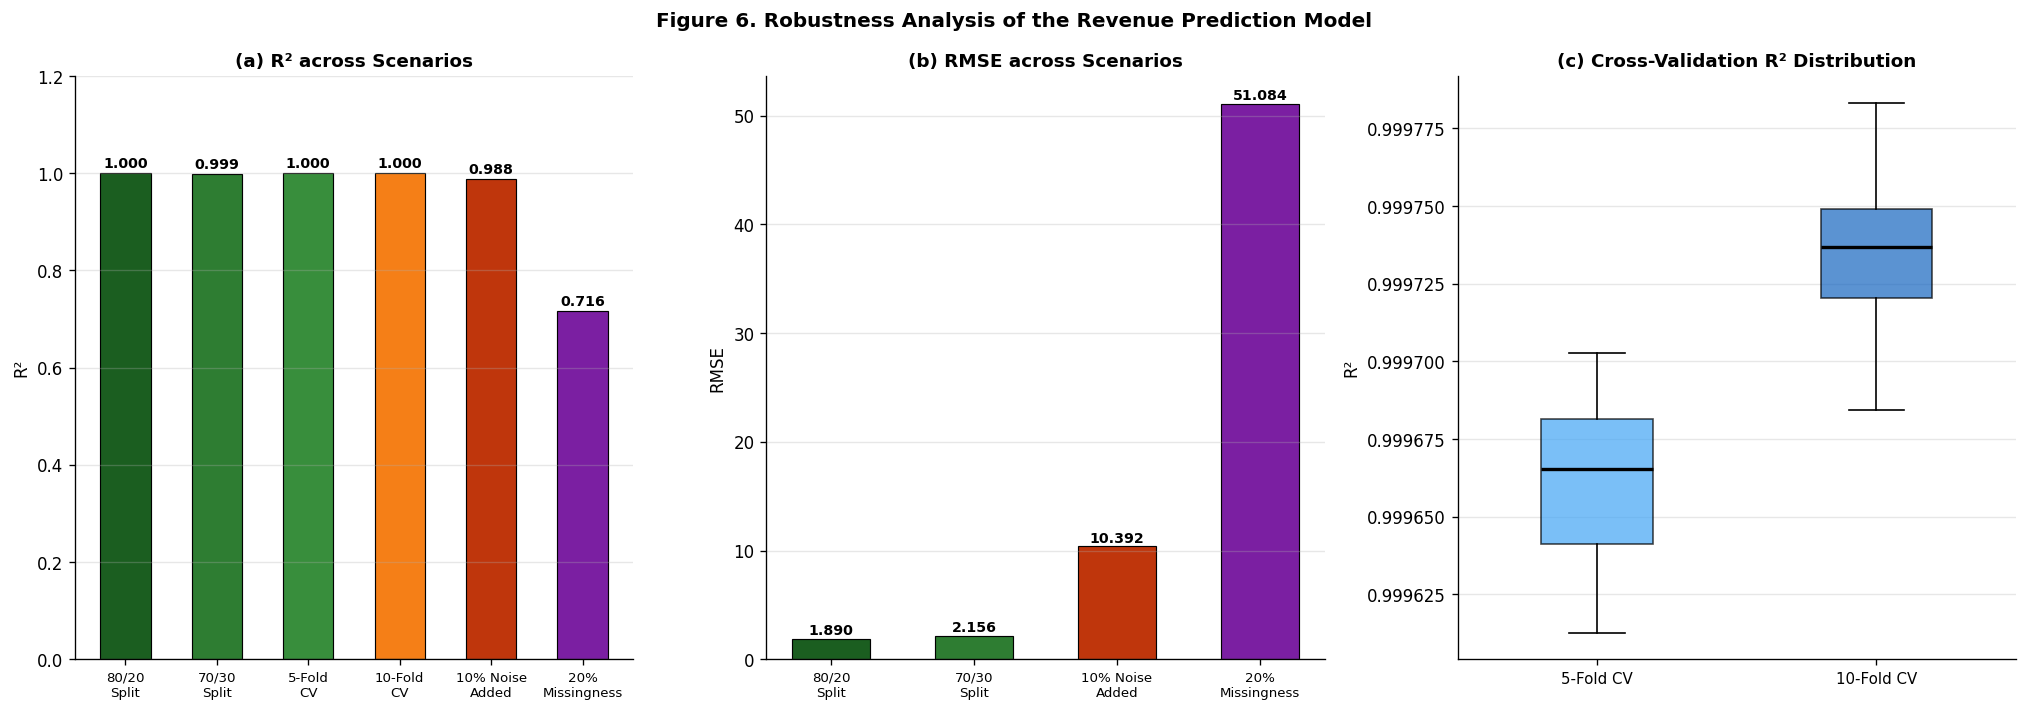

In [48]:
scenarios_lbl = ['80/20\nSplit','70/30\nSplit','5-Fold\nCV','10-Fold\nCV','10% Noise\nAdded','20%\nMissingness']
r2_vals   = Table_VI['R²'].tolist()
colors6   = ['#1B5E20','#2E7D32','#388E3C','#F57F17','#BF360C','#7B1FA2']

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Figure 6. Robustness Analysis of the Revenue Prediction Model', fontsize=12, fontweight='bold')

# Panel a: R²
ax1 = axes[0]
bars = ax1.bar(scenarios_lbl, r2_vals, color=colors6, edgecolor='black', linewidth=0.7, width=0.55)
for bar, v in zip(bars, r2_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{v:.3f}',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax1.set_title('(a) R² across Scenarios', fontsize=11, fontweight='bold')
ax1.set_ylabel('R²', fontsize=10); ax1.set_ylim(0, max(r2_vals)*1.2)
ax1.spines[['top','right']].set_visible(False); ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', labelsize=8)

# Panel b: RMSE (non-CV rows)
ax2 = axes[1]
t6_plot = Table_VI.dropna(subset=['RMSE']).reset_index()
rmse_labels = [scenarios_lbl[i] for i in t6_plot['index']]
bars2 = ax2.bar(rmse_labels, t6_plot['RMSE'], color=[colors6[i] for i in t6_plot['index']],
                edgecolor='black', linewidth=0.7, width=0.55)
for bar, v in zip(bars2, t6_plot['RMSE']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.3f}',
             ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax2.set_title('(b) RMSE across Scenarios', fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE', fontsize=10)
ax2.spines[['top','right']].set_visible(False); ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', labelsize=8)

# Panel c: CV boxplot
ax3 = axes[2]
bp = ax3.boxplot([cv5, cv10], patch_artist=True, widths=0.4,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#42A5F5','#1565C0']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax3.set_xticks([1,2]); ax3.set_xticklabels(['5-Fold CV','10-Fold CV'], fontsize=9)
ax3.set_title('(c) Cross-Validation R² Distribution', fontsize=11, fontweight='bold')
ax3.set_ylabel('R²', fontsize=10)
ax3.spines[['top','right']].set_visible(False); ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [49]:
criteria = ['Predictive\nAccuracy','Interpretability','Robustness',
            'Nonlinear\nModelling','Computational\nEfficiency',
            'Deployment\nSuitability','Managerial\nUsefulness']

scores = {
    'Linear\nRegression': [2,5,3,1,5,5,2],
    'Random\nForest':     [4,4,5,4,3,4,4],
    'Gradient\nBoosting': [5,3,4,5,2,3,4],
    'XGBoost':            [5,2,4,5,2,3,4],
}

Table_VII = pd.DataFrame(scores, index=criteria)
print("Table VII — RQ7 Decision Matrix")
display(Table_VII)


Table VII — RQ7 Decision Matrix


,Linear\nRegression,Random\nForest,Gradient\nBoosting,XGBoost
Predictive\nAccuracy,2,4,5,5
Interpretability,5,4,3,2
Robustness,3,5,4,4
Nonlinear\nModelling,1,4,5,5
Computational\nEfficiency,5,3,2,2
Deployment\nSuitability,5,4,3,3
Managerial\nUsefulness,2,4,4,4


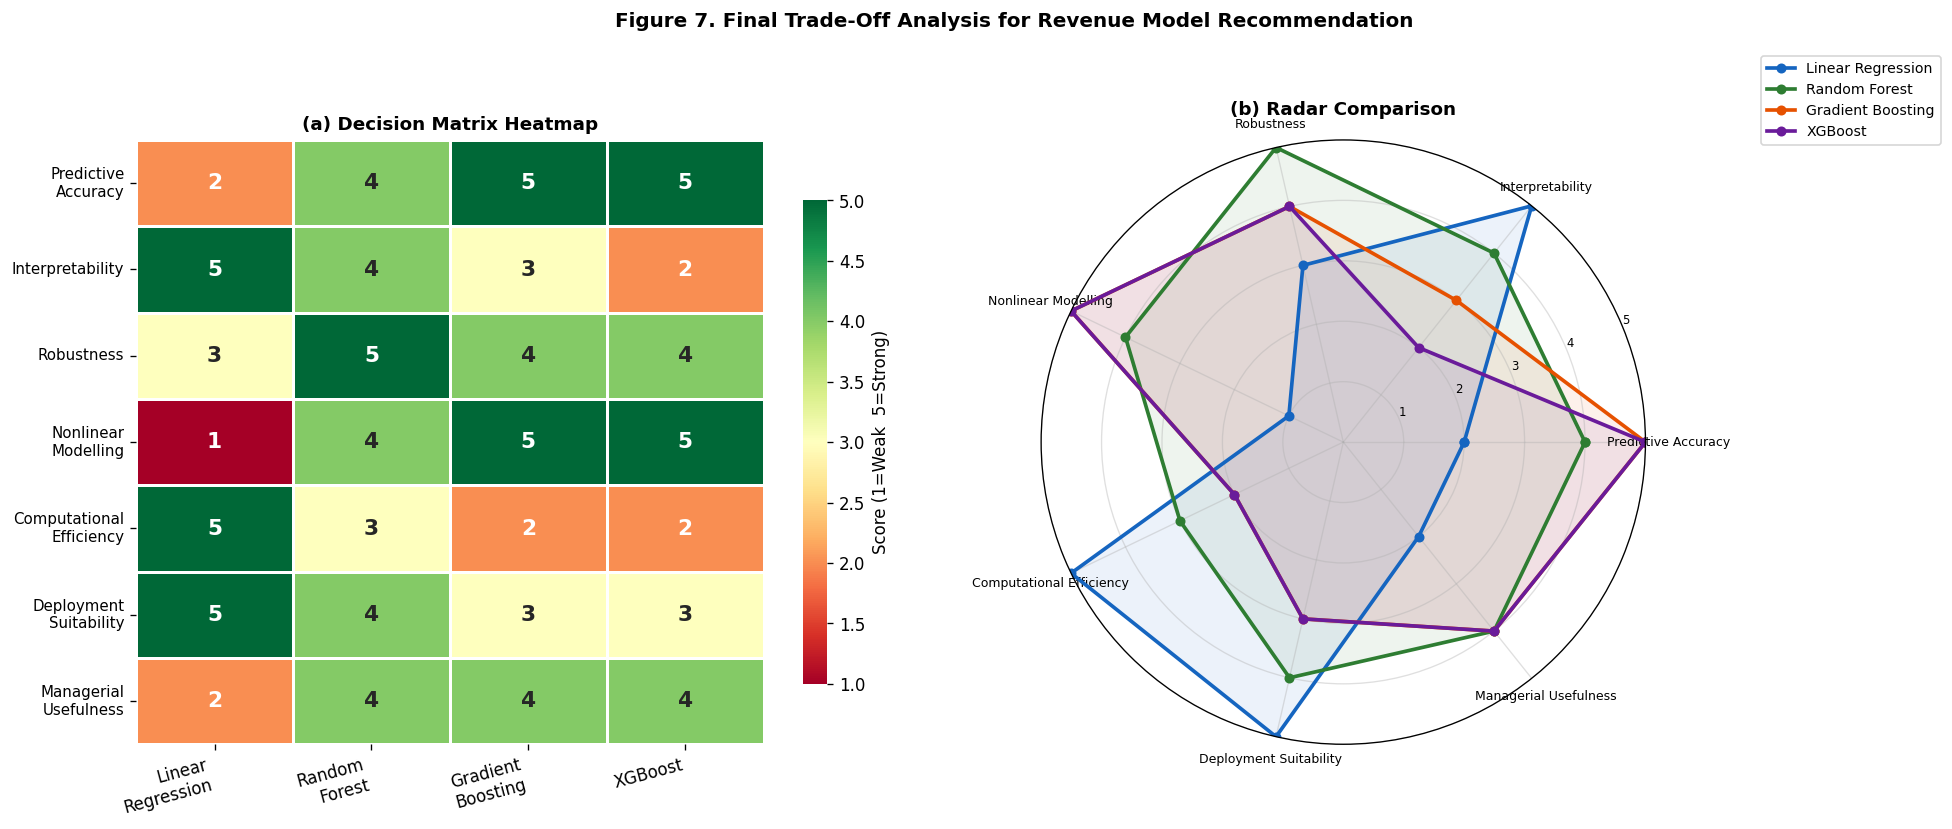

In [50]:
fig = plt.figure(figsize=(17, 7))
fig.suptitle('Figure 7. Final Trade-Off Analysis for Revenue Model Recommendation',
             fontsize=12, fontweight='bold')

# Heatmap
ax1 = fig.add_subplot(121)
sns.heatmap(Table_VII, annot=True, fmt='d', cmap='RdYlGn', vmin=1, vmax=5,
            linewidths=0.8, linecolor='white', ax=ax1,
            cbar_kws={'label':'Score (1=Weak  5=Strong)', 'shrink':0.8},
            annot_kws={'size':13, 'weight':'bold'})
ax1.set_title('(a) Decision Matrix Heatmap', fontsize=11, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right', fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0, fontsize=9)

# Radar
ax2 = fig.add_subplot(122, polar=True)
N = len(criteria)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
model_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A']
for (model, vals), color in zip(scores.items(), model_colors):
    vals_plot = vals + [vals[0]]
    ax2.plot(angles, vals_plot, 'o-', lw=2.2, color=color, label=model.replace('\n',' '), markersize=5)
    ax2.fill(angles, vals_plot, alpha=0.08, color=color)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels([c.replace('\n',' ') for c in criteria], fontsize=7.5)
ax2.set_yticks([1,2,3,4,5]); ax2.set_yticklabels(['1','2','3','4','5'], fontsize=7)
ax2.set_ylim(0, 5)
ax2.set_title('(b) Radar Comparison', fontsize=11, fontweight='bold', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8.5)
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()
